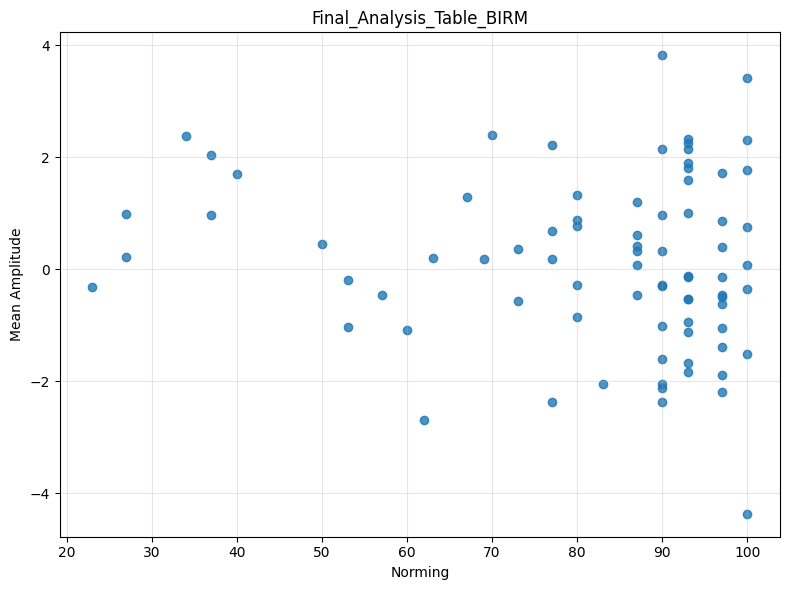

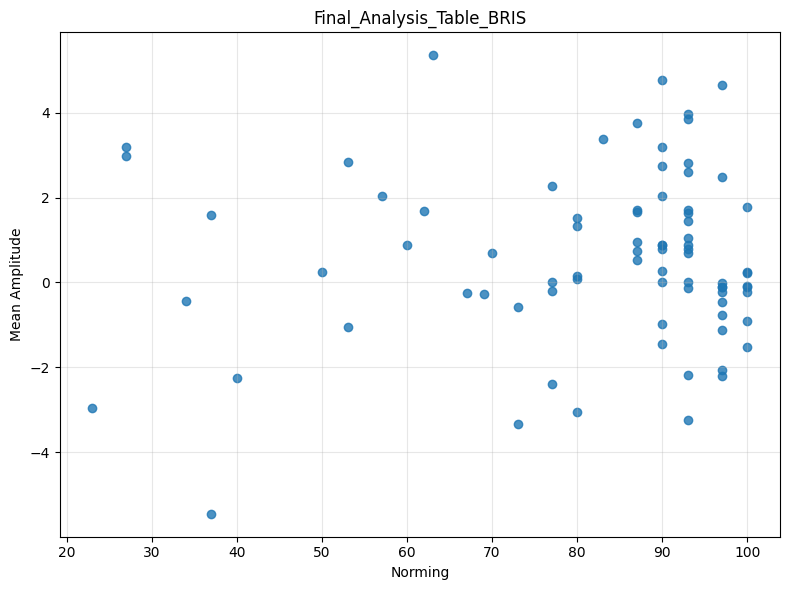

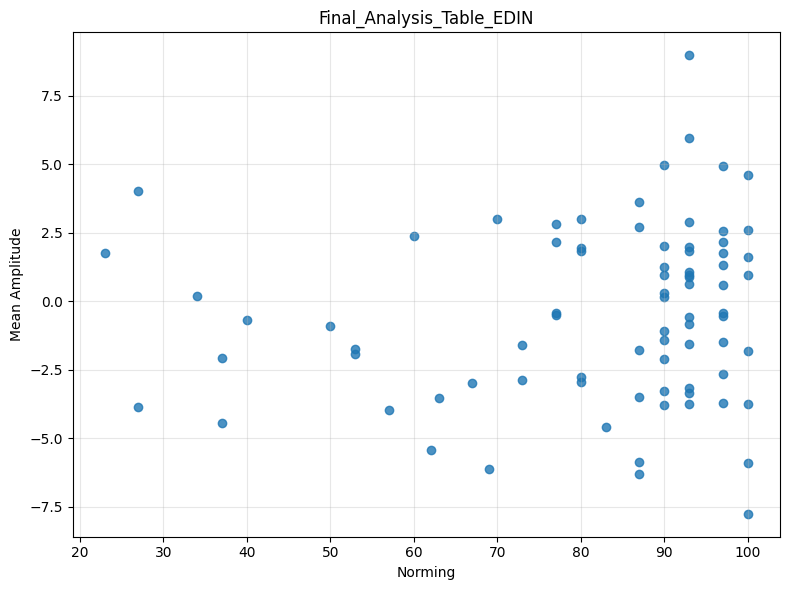

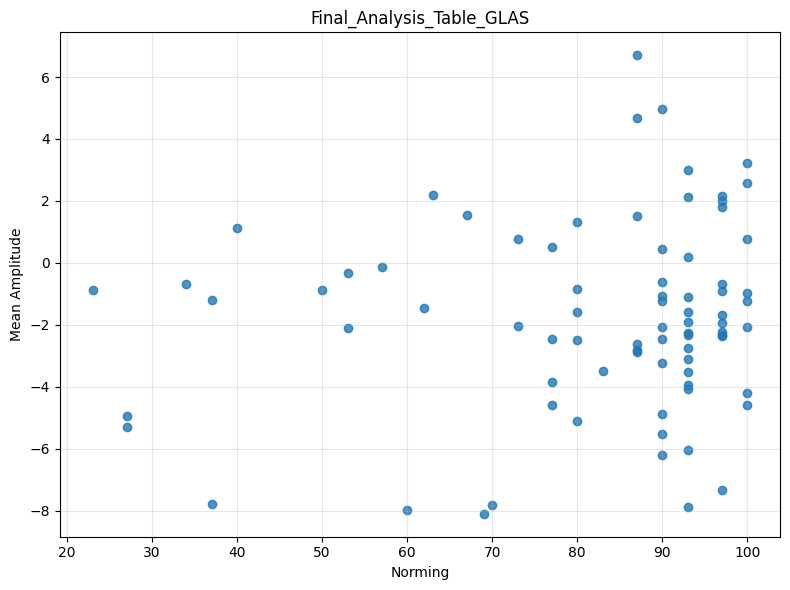

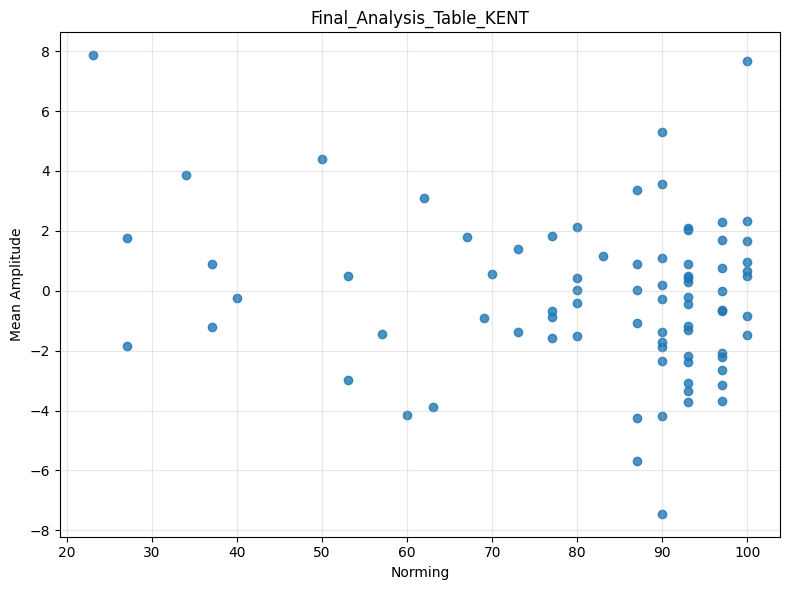

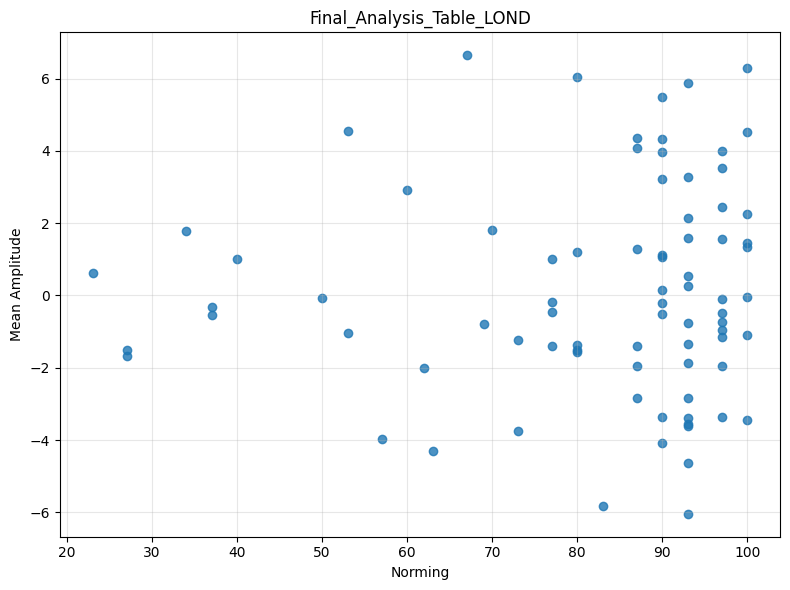

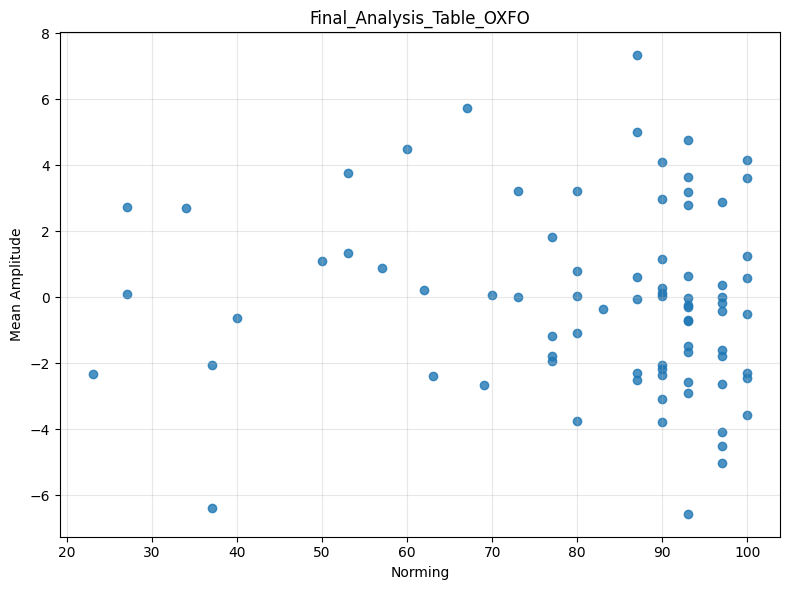

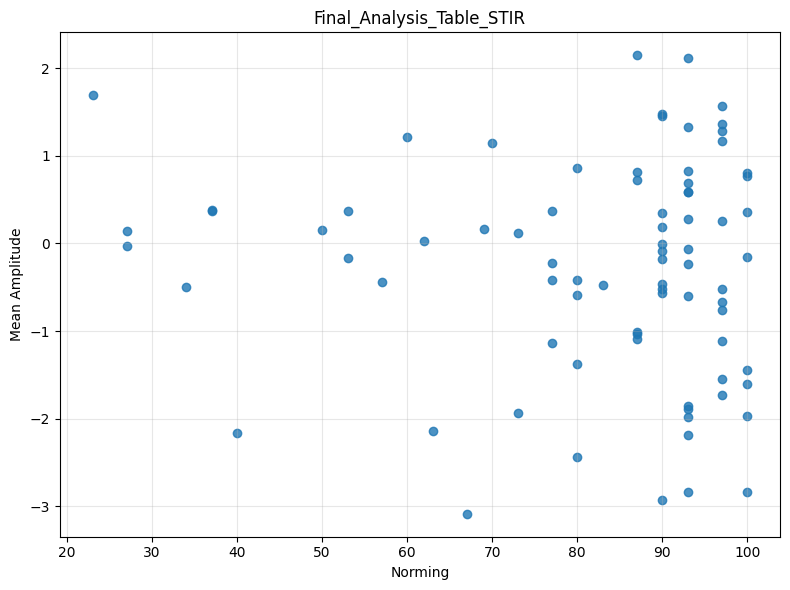

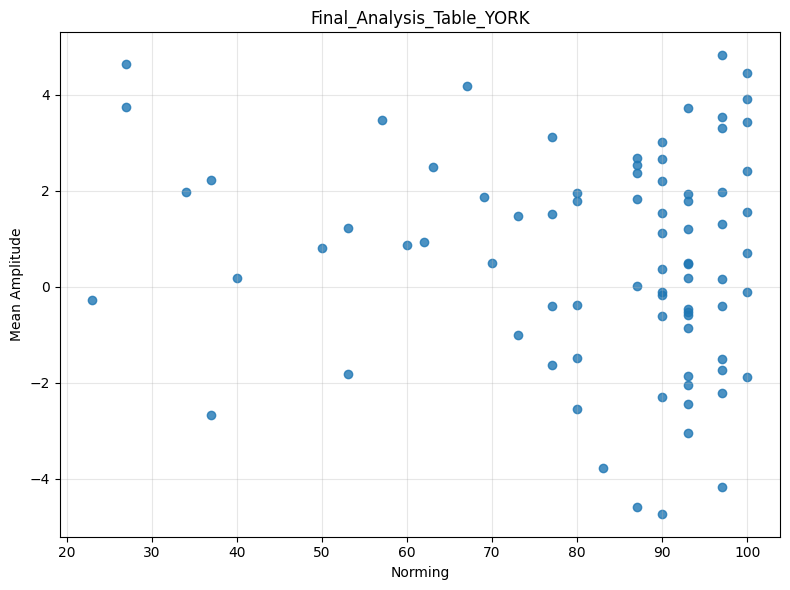

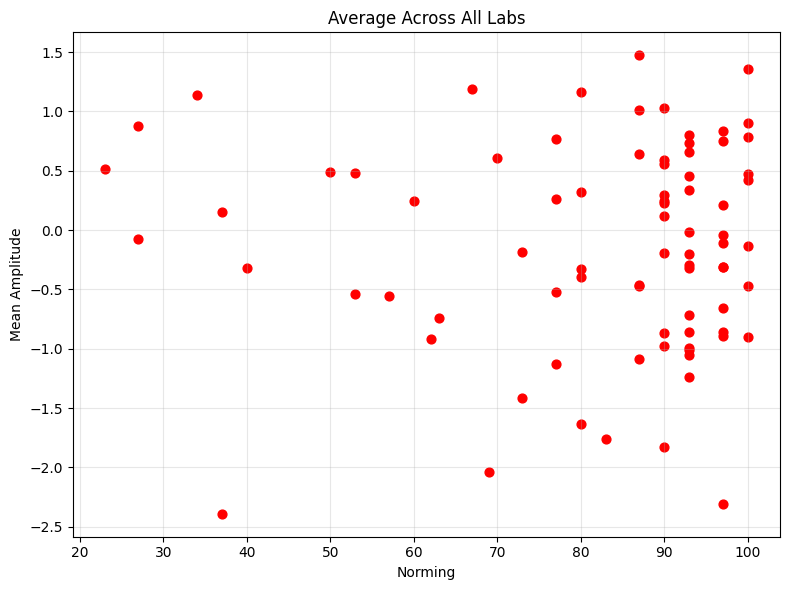

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# ==========================
# Load all tables
# ==========================

files = [
    "Final_Analysis_Table_BIRM.csv",
    "Final_Analysis_Table_BRIS.csv",
    "Final_Analysis_Table_EDIN.csv",
    "Final_Analysis_Table_GLAS.csv",
    "Final_Analysis_Table_KENT.csv",
    "Final_Analysis_Table_LOND.csv",
    "Final_Analysis_Table_OXFO.csv",
    "Final_Analysis_Table_STIR.csv",
    "Final_Analysis_Table_YORK.csv"
]

dfs = []

for f in files:
    df = pd.read_csv(f)

    # Keep only relevant columns
    df = df.iloc[:, [5,6,7]]      # F,G,H
    df.columns = ["Amplitude", "Item", "Norming"]

    # Add source (optional)
    df["Lab"] = os.path.basename(f)

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# ==========================
# Merge Norming for each Item
# ==========================

# Norming should be identical for each item across labs,
# but this also works if duplicated.
norming = (
    data.groupby("Item")["Norming"]
    .mean()
    .reset_index()
)

# ==========================
# Plot each lab separately
# ==========================

for lab in data["Lab"].unique():

    lab_df = (
        data[data["Lab"] == lab]
        .groupby("Item")["Amplitude"]
        .mean()
        .reset_index()
        .merge(norming, on="Item")
        .sort_values("Norming")
    )

    plt.figure(figsize=(8,6))

    plt.scatter(lab_df["Norming"],
                lab_df["Amplitude"],
                alpha=0.8)

    plt.xlabel("Norming")
    plt.ylabel("Mean Amplitude")
    plt.title(lab.replace(".csv",""))

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================
# Combined plot (average across labs)
# ==========================

combined = (
    data.groupby("Item")["Amplitude"]
    .mean()
    .reset_index()
    .merge(norming, on="Item")
    .sort_values("Norming")
)

plt.figure(figsize=(8,6))

plt.scatter(combined["Norming"],
            combined["Amplitude"],
            color="red",
            s=40)

plt.xlabel("Norming")
plt.ylabel("Mean Amplitude")
plt.title("Average Across All Labs")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

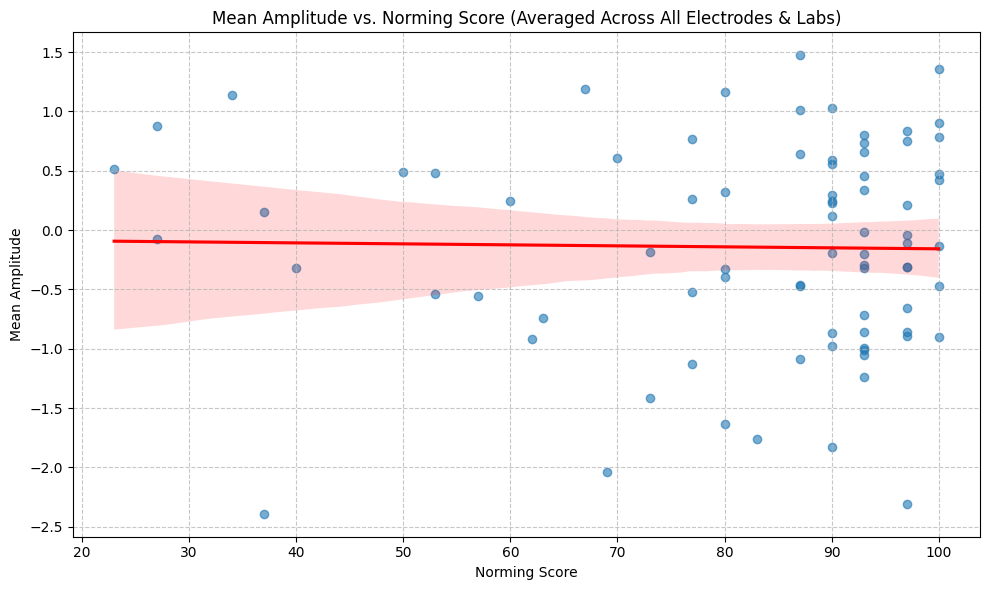

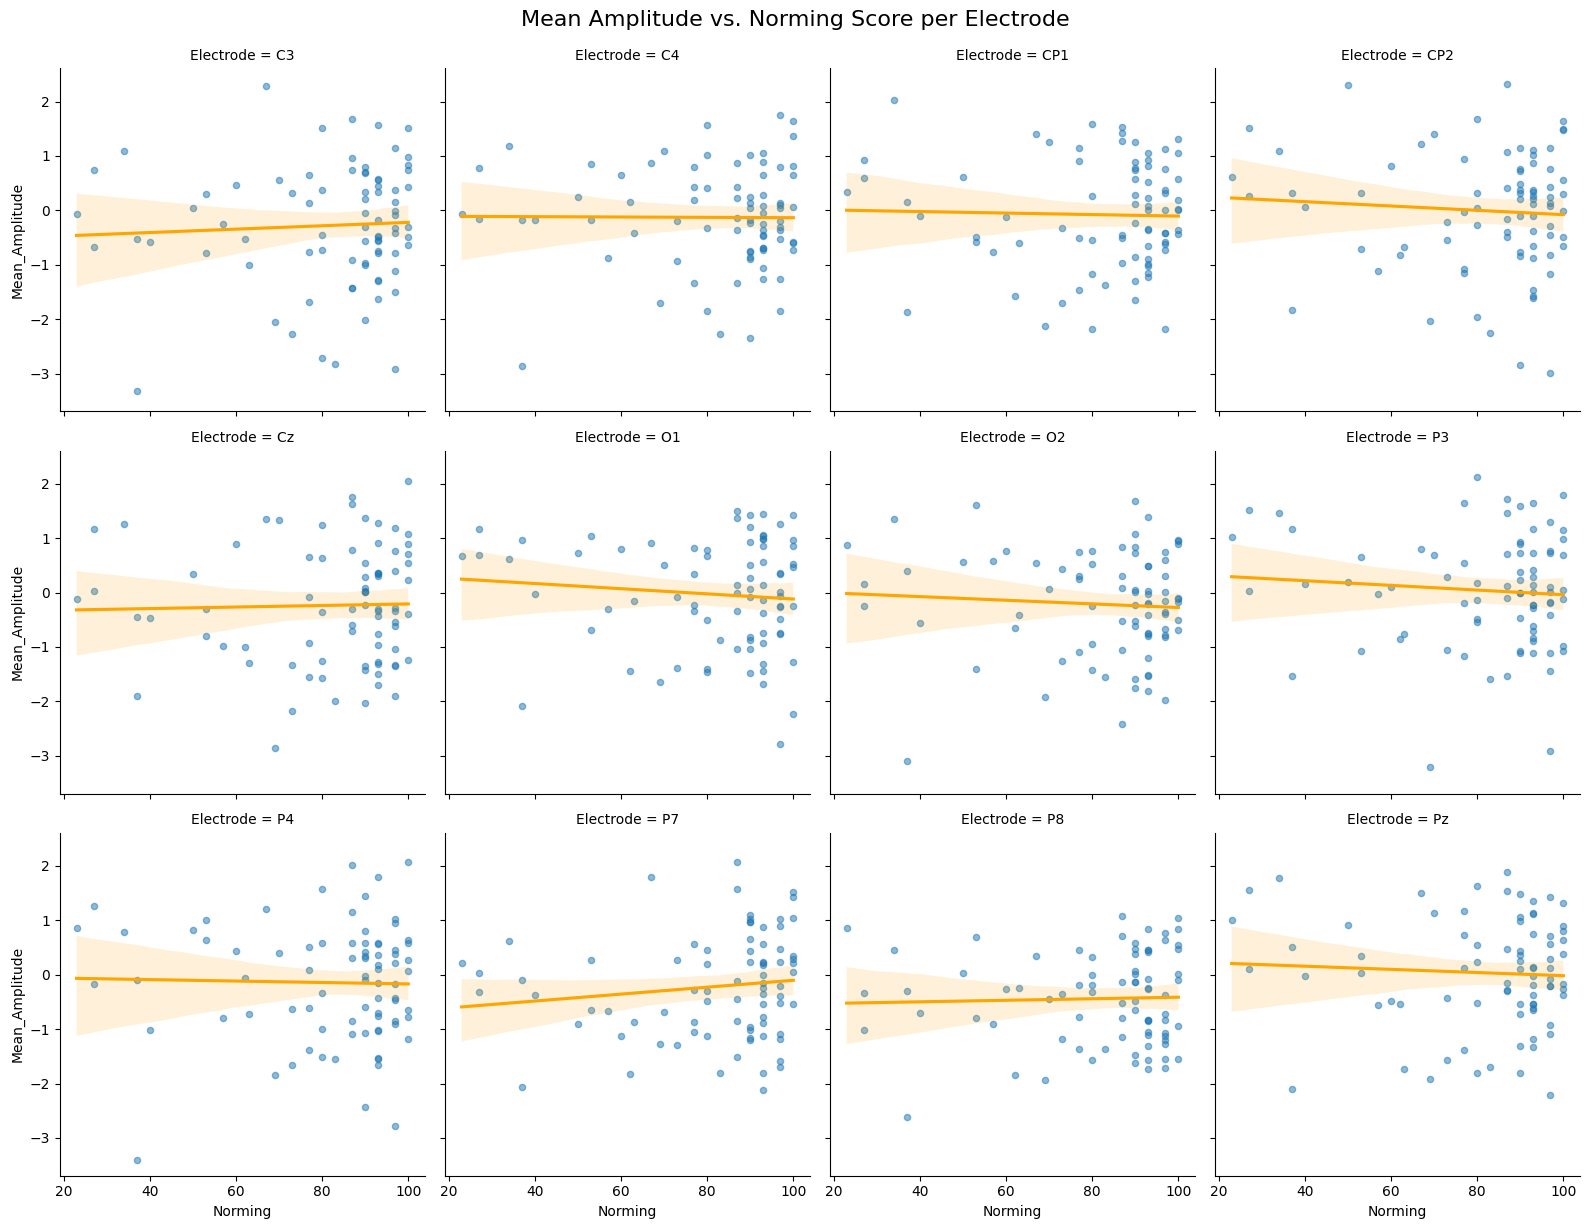

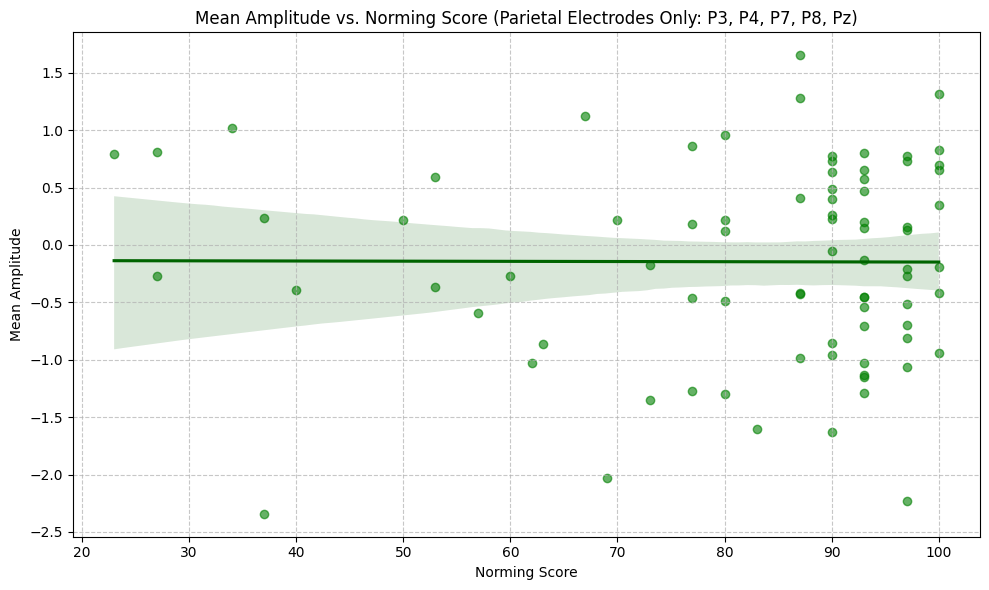


=== Summary Table: Item Number | Norming | Mean Amplitude ===
 Item_Number  Norming  Mean_Amplitude
         1.0     97.0           0.749
         2.0    100.0           0.477
         3.0    100.0          -0.904
         4.0     93.0           0.736
         5.0     93.0           0.800
         6.0    100.0           0.422
         7.0     80.0           0.323
         8.0     97.0           0.210
         9.0     93.0          -0.291
        10.0     80.0          -1.635
        11.0     87.0           1.474
        12.0    100.0           1.356
        13.0     97.0          -0.861
        14.0     90.0          -0.975
        15.0     90.0           0.116
        16.0     93.0          -1.051
        17.0     62.0          -0.914
        18.0     87.0           0.643
        19.0    100.0          -0.132
        20.0     90.0           0.294
        21.0     77.0          -0.520
        22.0     53.0          -0.540
        23.0     93.0          -0.998
        24.0     93.0    

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# רשימת הקבצים
files = [
    "Final_Analysis_Table_BIRM.csv",
    "Final_Analysis_Table_BRIS.csv",
    "Final_Analysis_Table_EDIN.csv",
    "Final_Analysis_Table_GLAS.csv",
    "Final_Analysis_Table_KENT.csv",
    "Final_Analysis_Table_LOND.csv",
    "Final_Analysis_Table_OXFO.csv",
    "Final_Analysis_Table_STIR.csv",
    "Final_Analysis_Table_YORK.csv"
]

dfs = []

# מעבר על כל הקבצים וקריאת הנתונים
for file in files:
    try:
        df = pd.read_csv(file)
        # חילוץ עמודות E (4), F (5), G (6), H (7) לפי אינדקס
        temp_df = df.iloc[:, [4, 5, 6, 7]].copy()
        # מתן שמות אחידים לעמודות כדי להקל על העבודה
        temp_df.columns = ['Electrode', 'Mean_Amplitude', 'Item_Number', 'Norming']
        dfs.append(temp_df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# איחוד כל הטבלאות ל-DataFrame אחד גדול
all_data = pd.concat(dfs, ignore_index=True)

# המרה למספרים למקרה שיש טקסט או ערכים חסרים, והסרת שורות ריקות (NaN)
all_data['Mean_Amplitude'] = pd.to_numeric(all_data['Mean_Amplitude'], errors='coerce')
all_data['Norming'] = pd.to_numeric(all_data['Norming'], errors='coerce')
all_data = all_data.dropna(subset=['Mean_Amplitude', 'Norming'])


# ==========================================
# 1. גרף מאוחד - ממוצע של כל האלקטרודות
# ==========================================
# חישוב הממוצע של האמפליטודה וציון הנורמינג עבור כל משפט (Item Number) בכל הקבצים
combined_avg = all_data.groupby('Item_Number')[['Norming', 'Mean_Amplitude']].mean().reset_index()

plt.figure(figsize=(10, 6))
# שימוש ב-regplot שגם מציג את הנקודות וגם מעביר קו מגמה ליניארי
sns.regplot(data=combined_avg, x='Norming', y='Mean_Amplitude',
            scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})

plt.title('Mean Amplitude vs. Norming Score (Averaged Across All Electrodes & Labs)')
plt.xlabel('Norming Score')
plt.ylabel('Mean Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# 2. גרפים לכל אלקטרודה בנפרד
# ==========================================
# חישוב ממוצע לכל משפט, אבל הפעם בהפרדה לפי אלקטרודה
electrode_avg = all_data.groupby(['Electrode', 'Item_Number'])[['Norming', 'Mean_Amplitude']].mean().reset_index()

# יצירת רשת של גרפים (FacetGrid) שבה כל חלונית מציגה אלקטרודה אחת
# col_wrap קובע כמה גרפים יהיו בשורה (אפשר לשנות בהתאם לכמות האלקטרודות)
g = sns.lmplot(
    data=electrode_avg,
    x='Norming',
    y='Mean_Amplitude',
    col='Electrode',
    col_wrap=4,
    scatter_kws={'alpha': 0.5, 's': 20}, # s = גודל הנקודה, alpha = שקיפות
    line_kws={'color': 'orange'},
    height=4,
    aspect=1
)

g.fig.suptitle('Mean Amplitude vs. Norming Score per Electrode', y=1.02, fontsize=16)
plt.show()

# ==========================================
# 2.5 גרף חדש - אלקטרודות פריאטליות בלבד (P3, P4, P7, P8, Pz)
# ==========================================
parietal_electrodes = ['P3', 'P4', 'P7', 'P8', 'Pz', 'PZ'] # כולל וריאציות כתיב
parietal_data = all_data[all_data['Electrode'].isin(parietal_electrodes)].copy()

parietal_avg = parietal_data.groupby('Item_Number')[['Norming', 'Mean_Amplitude']].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.regplot(data=parietal_avg, x='Norming', y='Mean_Amplitude',
            scatter_kws={'alpha':0.6, 'color': 'green'}, line_kws={'color': 'darkgreen'})

plt.title('Mean Amplitude vs. Norming Score (Parietal Electrodes Only: P3, P4, P7, P8, Pz)')
plt.xlabel('Norming Score')
plt.ylabel('Mean Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# 3. יצירת טבלת הסיכום והדפסתה
# ==========================================
# חישוב הממוצע של האמפליטודה וציון הנורמינג עבור כל משפט מכל המעבדות והאלקטרודות
combined_avg = all_data.groupby('Item_Number')[['Norming', 'Mean_Amplitude']].mean().reset_index()

# סידור הטבלה לפי מספרי המשפטים בסדר עולה
combined_avg = combined_avg.sort_values(by='Item_Number')

# הדפסה למסך של הטבלה (מעוגל ל-3 ספרות אחרי הנקודה לנוחות קריאה)
print("\n=== Summary Table: Item Number | Norming | Mean Amplitude ===")
print(combined_avg.round(3).to_string(index=False))

# שמירת הטבלה לקובץ CSV חדש (אופציונלי - מאוד נוח אם תרצה לפתוח את זה אחר כך באקסל)
combined_avg.to_csv("Combined_Averages_Summary.csv", index=False)
print("\nTable successfully saved to 'Combined_Averages_Summary.csv'\n")